In [1]:
# Abra o arquivo json/arquivos_ftp.json e formate para dataframe
import json
import pandas as pd

with open('json/arquivos_ftp.json') as f:
    data = json.load(f)

df = pd.DataFrame(data)


In [14]:
# Select all is_historico == False
df[(df['is_historico'] == False) & (df['estacao'] == 'orn')]

,caminho,estacao,is_historico,tipo_dado
1885,/restricted/coleta/orn/data/ORN_AMB_10.DAT,orn,False,AMB
1886,/restricted/coleta/orn/data/ORN_ANE_10.DAT,orn,False,ANE
1887,/restricted/coleta/orn/data/ORN_MD.DAT,orn,False,MD
1888,/restricted/coleta/orn/data/ORN_RAD_01.DAT,orn,False,RAD
1889,/restricted/coleta/orn/data/ORN_SD.DAT,orn,False,SD
1890,/restricted/coleta/orn/data/ORN_SUP_01.DAT,orn,False,RAW
1891,/restricted/coleta/orn/data/ORN_TD.DAT,orn,False,TD
1892,/restricted/coleta/orn/data/ORN_WD.DAT,orn,False,RAW


In [ ]:
!pip install duckdb

In [ ]:
import duckdb

In [6]:
dados = "ftp/restricted/coleta/spk/data/historico/2023/SPK_2023_001_a_241_RAD_01.dat"
data = duckdb.query(f"""
        SELECT * 
        FROM read_csv_auto('{dados}',
        ignore_errors=true)
        LIMIT 10
    """)
data

┌─────────────────────┬─────────┬─────────┬─────────┬────────────┬─────────┬───────────┬────────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬───────────┬────────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────────────┬────────────────┬────────────────┬────────────────┬─────────┬─────────┬─────────┬─────────┬───────────┬────────────┬──────────┬──────────┬────────────┬────────────┬────────────┬────────────┬─────────┬──────────┐
│      TIMESTAMP      │ RECORD  │   ID    │   Ano   │ DiaJuliano │  Min01  │  glo_avg  │  glo_std   │ glo_min  │ glo_max  │ dif_avg  │ dif_std  │ dif_min  │ dif_max  │  dir_avg  │  dir_std   │ dir_min  │ dir_max  │  lw_avg  │  lw_std  │  lw_min  │  lw_max  │    par_avg     │    par_std     │    par_min     │    par_max     │ lux_avg │ lux_std │ lux_min │ lux_max │ tilt_avg  │  tilt_std  │ tilt_min │ tilt_max │ lwcalc_avg │ lwcalc_std │ lwcalc_min │ lwcalc_max │ tp_dir  │  tp_lw   │
│       varchar       │ va

In [4]:
dados = "ftp/restricted/coleta/sjc/data/GUI_RAD_01.DAT"
data = duckdb.query(f"""
        SELECT * 
        FROM read_csv_auto('{dados}',
        ignore_errors=true)
    """)
data

┌─────────────────────┬─────────┬─────────┬─────────┬────────────┬─────────┬─────────────┬──────────────┬───────────────┬────────────┬───────────┬──────────┬───────────┬───────────┬───────────┬──────────┬───────────┬───────────┬──────────┬──────────┬──────────┬──────────┬────────────────┬────────────────┬────────────────┬────────────────┬─────────┬─────────┬─────────┬─────────┬────────────┬──────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬────────────┬──────────┬─────────┐
│      TIMESTAMP      │ RECORD  │   ID    │   Ano   │ DiaJuliano │  Min01  │   glo_avg   │   glo_std    │    glo_min    │  glo_max   │  dif_avg  │ dif_std  │  dif_min  │  dif_max  │  dir_avg  │ dir_std  │  dir_min  │  dir_max  │  lw_avg  │  lw_std  │  lw_min  │  lw_max  │    par_avg     │    par_std     │    par_min     │    par_max     │ lux_avg │ lux_std │ lux_min │ lux_max │  tilt_avg  │   tilt_std   │ tilt_min  │  tilt_max  │ lwcalc_avg │ lwcalc_std │ lwcalc_min │ lwcalc_max │  tp_dir

In [94]:
data

┌─────────────────────┬──────────┬──────────┬──────────┬────────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬───────────┬─────────────┬───────────┬───────────┬──────────┬────────────┬──────────┬──────────┬────────────────┬────────────────┬────────────────┬────────────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┐
│      column00       │ column01 │ column02 │ column03 │  column04  │ column05 │ column06 │ column07 │ column08 │ column09 │ column10 │ column11 │ column12 │ column13 │ column14  │  column15   │ column16  │ column17  │ column18 │  column19  │ column20 │ column21 │    column22    │    column23    │    column24    │    column25    │ column26 │ column27 │ column28 │ column29 │ column30 │ column31 │ column32 │ column33 │  column34  │  column35  │  column36  │  column37  │ column38 │ column39 │
│       va

In [65]:
import pandas as pd

In [67]:
data = data.iloc[3:]

# Convert all columns to numeric
data = data.apply(pd.to_numeric, errors='ignore')

/tmp/ipykernel_195132/1883632728.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors='ignore')


In [71]:
# set timestamp as index
data['TIMESTAMP'] = pd.to_datetime(data['TIMESTAMP'])
data = data.set_index('TIMESTAMP')

In [79]:
data.columns

Index(['RECORD', 'Id', 'Year', 'Jday', 'Min', 'glo_avg', 'glo_std', 'glo_min',
       'glo_max', 'dif_avg', 'dif_std', 'dif_min', 'dif_max', 'dir_avg',
       'dir_std', 'dir_min', 'dir_max', 'lw_raw_avg', 'lw_raw_std',
       'lw_raw_min', 'lw_raw_max', 'par_avg', 'par_std', 'par_min', 'par_max',
       'lux_avg', 'lux_std', 'lux_min', 'lux_max', 'tilt_avg', 'tilt_std',
       'tilt_min', 'tilt_max', 'lw_calc_avg', 'lw_calc_std', 'lw_calc_min',
       'lw_calc_max', 'tp_dir', 'tp_lw_case'],
      dtype='object')

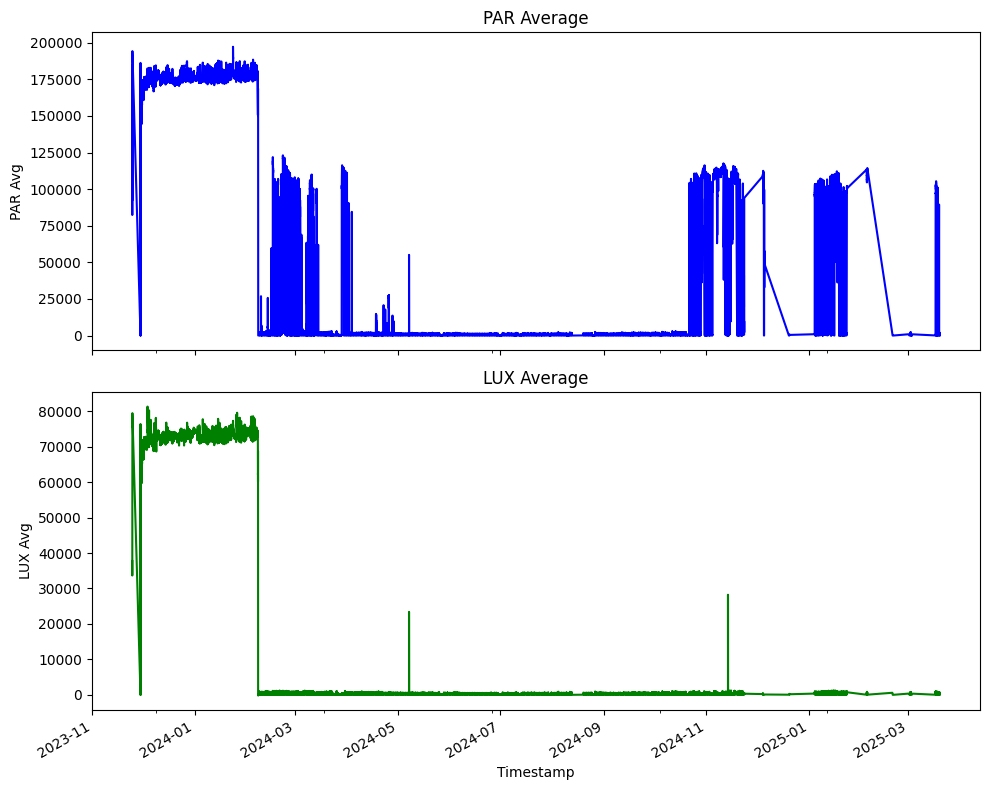

In [77]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot par_avg
data['par_avg'].plot(ax=axes[0], title='PAR Average', color='blue')
axes[0].set_ylabel('PAR Avg')

# Plot lux_avg
data['lux_avg'].plot(ax=axes[1], title='LUX Average', color='green')
axes[1].set_ylabel('LUX Avg')
axes[1].set_xlabel('Timestamp')

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

In [4]:
pd.read_parquet('../output/sonda-banco-dados/Solarimetrica.parquet')

,acronym,timestamp,year,day,min,glo_avg,glo_std,glo_max,glo_min,dif_avg,...,lw_calc_min,lw_raw_avg,lw_raw_std,lw_raw_max,lw_raw_min,tp_glo,tp_dir,tp_dif,tp_lw_dome,tp_lw_case
0,None,NaT,NaN,NaN,NaN,pir_thermpil,pir_thermpil,pir_thermpil,pir_thermpil,pir_shdtrker\npir_shdring,...,prg_shdtrker,prg_shdtrker,prg_shdtrker,prg_shdtrker,prg_shdtrker,tcp_sensor,tcp_sensor,tcp_sensor,tcp_sensor,tcp_sensor
1,STM,2023-01-01 00:00:00,2023.0,1.0,0.0,-0.8763304,0.006651296,-0.8597959,-0.8886021,-0.5594233,...,417.1403,-28.10634,0.4215963,-27.38456,-28.80793,None,23.58936,None,None,24.65125
2,STM,2023-01-01 00:01:00,2023.0,1.0,1.0,-0.8951229,0.007425136,-0.8739498,-0.9103916,-0.5400724,...,418.5981,-26.62953,0.4556733,-25.80449,-27.35925,None,23.59125,None,None,24.65276
3,STM,2023-01-01 00:02:00,2023.0,1.0,2.0,-0.895914,0.006834456,-0.8821289,-0.9141233,-0.5262945,...,420.2126,-24.75095,0.5822951,-23.74794,-25.7541,None,23.58874,None,None,24.65419
4,STM,2023-01-01 00:03:00,2023.0,1.0,3.0,-0.8787194,0.008650859,-0.86356,-0.8998249,-0.518088,...,422.2718,-22.80426,0.4926083,-21.97622,-23.70241,None,23.58406,None,None,24.65595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48498,STM,2023-03-15 13:47:00,2023.0,74.0,827.0,474.6719,2.165077,477.8867,470.8395,494.1797,...,438.2517,-44.4882,0.229847,-44.1477,-44.87005,None,30.112,None,None,30.68841
48499,STM,2023-03-15 13:51:00,2023.0,74.0,831.0,491.6043,1.261801,493.6748,489.2661,514.3013,...,437.9059,-46.11311,0.2434792,-45.75461,-46.50575,None,30.22462,None,None,30.89412
48500,STM,2023-03-27 13:35:00,2023.0,86.0,815.0,223.2671,0.3708665,223.9387,222.6721,238.1142,...,441.2061,-29.02524,0.07899284,-28.74184,-29.13228,None,27.32968,None,None,28.64005
48501,STM,2023-03-28 11:12:00,2023.0,87.0,672.0,270.1334,8.808049,296.3362,262.9817,116.4072,...,431.6804,-14.57733,0.03438459,-14.52612,-14.63514,None,23.88415,None,None,24.72359


In [1]:
import duckdb

In [6]:
base_dados = "../output/sonda-banco-dados/Solarimetrica.parquet"

base_2 = "../output/sonda-banco-dados/Solarimetrica_2.parquet"

In [8]:
# Cria conexão com o banco de dados DuckDB
con = duckdb.connect()

In [9]:
# Executa a consulta para remover duplicatas e salva o resultado
con.execute(f"""
    COPY (
        SELECT DISTINCT *
        FROM read_parquet('{base_dados}')
    )
    TO '{base_2}' (FORMAT 'parquet');
""")

In [12]:
# Verifica diferenca no numero de linhas da base_dados e base_2
base_dados_linhas = con.execute(f"""
    SELECT COUNT(*) AS num_linhas
    FROM read_parquet('{base_dados}')
""").fetchone()[0]
base_2_linhas = con.execute(f"""
    SELECT COUNT(*) AS num_linhas
    FROM read_parquet('{base_2}')
""").fetchone()[0]
print(f"Base de dados original: {base_dados_linhas} linhas")
print(f"Base de dados sem duplicatas: {base_2_linhas} linhas")

Base de dados original: 71291129 linhas
Base de dados sem duplicatas: 64717182 linhas


In [11]:
# Verifica diferenca no numero de linhas da base_2
base_2_linhas = con.execute(f"""
    SELECT COUNT(*) AS num_linhas
    FROM read_parquet('{base_2}')
""").fetchone()[0]
print(f"Número de linhas em {base_dados}: {base_dados_linhas}")

Número de linhas em ../output/sonda-banco-dados/Solarimetrica.parquet: 71291129
